# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 4. Матричный профиль. Поиск примитивов на его основе.**

Смените рабочую директорию с помощью команды `chdir()`. Для этого передайте этой команде свой путь до каталога, в котором содержатся материалы четвертой практической работы. После выполнения этой команды все последующие операции с файлами и каталогами будут производиться относительно указанного каталога.

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import os

practice_dir_path = '/content/drive/MyDrive/2025-Murzin-TimeSeriesCourse-main/practice/04 Matrix profile'
os.chdir(practice_dir_path)

In [19]:
!pwd

/content/drive/MyDrive/2025-Murzin-TimeSeriesCourse-main/practice/04 Matrix profile


Выполните команды, которые автоматически перезагружают все импортированные модули при их изменении.

In [ ]:
#%load_ext autoreload
#%autoreload 2

Импортируйте библиотеки и модули, необходимые для реализации практической работы 4.

In [4]:
!pip install stumpy

In [20]:
import pandas as pd
import numpy as np
import os
import datetime

from modules.plots import *
from modules.mp import compute_mp
from modules.motifs import top_k_motifs
from modules.discords import top_k_discords
from modules.meter_swapping_detection import *

## **Часть 1.** Матричный профиль. Поиск мотивов и диссонансов.

### **Задача 1.**
Загрузите временной ряд, который содержит данные о почасовом потреблении электроэнергии некоторого итальянского города, снимаемые в течение 3 лет, начиная с 1 января 1995 года.

In [21]:
ts_url = './datasets/part1/italianpowerdemand.csv'

ts = pd.read_csv(ts_url, header=None).squeeze().to_numpy()

Визуализируйте временной ряд, используя функцию `plot_ts()` из модуля *plot.py*.

In [22]:
plot_ts(ts, "Input time series")

Анализ временных рядов на основе матричного профиля осуществляет библиотека [stumpy](https://stumpy.readthedocs.io/en/latest/index.html). Напишите функцию `compute_mp()` в модуле *mp.py*, которая вычисляет матричный профиль временного ряда на основе выбранной вами функции из библиотеки *stumpy*.

In [23]:
# @title
import numpy as np
import pandas as pd
import math

import stumpy
from stumpy import config

def compute_mp(ts1: np.ndarray, m: int, exclusion_zone: int = None, ts2: np.ndarray = None):
    """
    Compute the matrix profile

    Parameters
    ----------
    ts1: the first time series
    m: the subsequence length
    exclusion_zone: exclusion zone
    ts2: the second time series

    Returns
    -------
    output: the matrix profile structure
            (matrix profile, matrix profile index, subsequence length, exclusion zone, the first and second time series)
    """

    # INSERT YOUR CODE
    if exclusion_zone is None:
        exclusion_zone = math.ceil(m / config.STUMPY_EXCL_ZONE_DENOM)

    if ts2 is None:
        mp = stumpy.stump(ts1, m)
    else:
        mp = stumpy.stump(ts1, m, ts2)

    return {'mp': mp[:, 0],
            'mpi': mp[:, 1],
            'm' : m,
            'excl_zone': exclusion_zone,
            'data': {'ts1' : ts1, 'ts2' : ts2}
            }

In [24]:
m = 165
excl_zone = int(np.ceil(m / 2))
mp = {}

# INSERT YOUR CODE

mp = compute_mp(ts, excl_zone)
mp_df = pd.DataFrame({
    'matrix_profile': mp['mp'],
    'matrix_profile_index': mp['mpi']
})
mp_df.index = range(len(mp_df))

print(f"Основные статистики матричного профиля:\n{mp_df.describe()}")

nl = 10
print(f"Первые {nl} строк матричного профиля:\n{mp_df.head(nl)}")

top_n = 3

mt_idx = mp_df['matrix_profile'].argsort()[:top_n]
print(f"\nТоп-{top_n} мотива (индексы): {mt_idx.tolist()}")
print(f"Значения матр. профиля мотивов: {mp_df.iloc[mt_idx]['matrix_profile'].values}")

discords_idx = mp_df['matrix_profile'].argsort()[-1 * top_n:][::-1]
print(f"\nТоп-{top_n} аномалий (индексы): {discords_idx.tolist()}")
print(f"Значения матр. профиля аномалий: {mp_df.iloc[discords_idx]['matrix_profile'].values}")

Основные статистики матричного профиля:
        matrix_profile  matrix_profile_index
count     29849.000000                 29849
unique    24592.000000                 16384
top           3.488037                 19971
freq          4.000000                    10
Первые 10 строк матричного профиля:
  matrix_profile matrix_profile_index
0       1.622457                 8761
1       1.582633                 8762
2       1.573116                 8763
3       1.578031                 8764
4       1.588465                 8765
5        1.60889                 8766
6       1.618108                 8767
7       1.663393                 8768
8       1.645045                 8769
9       1.635535                 8770

Топ-3 мотива (индексы): [27684, 18611, 18612]
Значения матр. профиля мотивов: [0.7190757870651278 0.7190757870651278 0.7240544043508732]

Топ-3 аномалий (индексы): [14210, 14209, 14211]
Значения матр. профиля аномалий: [6.8432704350018705 6.813307734902267 6.649858879283441]


Визуализируйте найденный матричный профиль ряда.

In [25]:
plot_ts(mp['mp'], "Matrix Profile")

### **Задача 2.**
Выполните поиск top-$k$ мотивов в исходном временном ряде на основе построенного матричного профиля. Для этого реализуйте самостоятельно функцию `top_k_motifs()` в модуле *motifs.py*. Среди найденных мотивов не должно быть тривиальных совпадений, поэтому в `top_k_motifs()` добавьте вызов функции `apply_exclusion_zone()` из модуля *utils.py*.

In [29]:
# @title
def top_k_motifs(matrix_profile: dict, top_k: int = 3) -> dict:
    """
    Find the top-k motifs based on matrix profile

    Parameters
    ---------
    matrix_profile: the matrix profile structure
    top_k : number of motifs

    Returns
    --------
    motifs: top-k motifs (left and right indices and distances)
    """

    motifs_idx = []
    motifs_dist = []

    # INSERT YOUR CODE

    mp = matrix_profile['mp']
    mp_len = len(mp)

    mp_temp = mp.copy()

    for i in range(top_k):
        min_idx = np.argmin(mp_temp)
        min_dist = mp_temp[min_idx]

        if 'pi' in matrix_profile:
            nn_idx = matrix_profile['pi'][min_idx]
        else:
            nn_idx = min_idx

        motif_pair = sorted([min_idx, nn_idx])
        motifs_idx.append(motif_pair)
        motifs_dist.append(min_dist)

        excl_zone = matrix_profile.get('excl_zone', mp_len // 2)
        exclusion_value = np.max(mp_temp)

        mp_temp = apply_exclusion_zone(mp_temp, motif_pair[0], excl_zone, exclusion_value)
        mp_temp = apply_exclusion_zone(mp_temp, motif_pair[1], excl_zone, exclusion_value)

    return {
        "indices" : motifs_idx,
        "distances" : motifs_dist
        }


In [26]:
# @title
def apply_exclusion_zone(a: np.ndarray, idx: int, excl_zone: int, val: float) -> np.ndarray:
    """
    Set all values of array to `val` in a window around a given index

    Parameters
    ----------
    a: array
    idx: the index around which the window should be centered
    excl_zone: size of the exclusion zone
    val: the elements within the exclusion zone will be set to this value

    Returns
    -------
    a: array that is applied an exclusion zone
    """

    zone_start = max(0, idx - excl_zone)
    zone_stop = min(a.shape[-1], idx + excl_zone)

    a[zone_start : zone_stop + 1] = val

    return a

In [30]:
top_k = 6
motifs = top_k_motifs(mp, top_k=top_k)

# INSERT YOUR CODE
print(f"Топ-{top_k} мотивов найдено:")
for i, (indices, distance) in enumerate(zip(motifs['indices'], motifs['distances'])):
    print(f"Мотив {i+1}: indices {indices}, distance {distance:.4f}")

Топ-6 мотивов найдено:
Мотив 1: indices [np.int64(18611), np.int64(18611)], distance 0.7191
Мотив 2: indices [np.int64(27684), np.int64(27684)], distance 0.7191
Мотив 3: indices [np.int64(19437), np.int64(19437)], distance 0.7281
Мотив 4: indices [np.int64(28006), np.int64(28006)], distance 0.7281
Мотив 5: indices [np.int64(18746), np.int64(18746)], distance 0.7318
Мотив 6: indices [np.int64(18914), np.int64(18914)], distance 0.7318


Выполните визуализацию найденных top-$k$ мотивов с помощью функции `plot_motifs()` из *plots.py*.

In [34]:
# @title
def plot_motifs(mp: dict, top_k_motifs: dict) -> None:
    """
    Plot the top-k motifs in time series and matrix profile

    Parameters
    ----------
    mp: the matrix profile structure
    top_k_motifs: top-k motifs
    """

    top_k = len(top_k_motifs['indices'])
    n = len(mp['data']['ts1'])
    m = mp['m']

    num_cols = 2
    num_rows = 2 + math.ceil(top_k / num_cols)

    titles = ['Time Series with top-k motifs', 'Matrix Profile'] + [f"Top-{i+1} motifs" for i in range(top_k)]

    fig = make_subplots(
        rows=num_rows, cols=num_cols,
        specs=[[{"colspan": 2}, None]]*2 + [[{}, {}]]*(num_rows-2),
        shared_xaxes=False,
        vertical_spacing=0.1,
        subplot_titles=titles
    )

    # Основной временной ряд
    fig.add_trace(
        go.Scatter(x=np.arange(n), y=mp['data']['ts1'], line=dict(color='grey'), name="Time Series"),
        row=1, col=1
    )

    # Отображение топ-K мотивов на временном ряде
    for i in range(top_k):
        left_motif_idx = top_k_motifs['indices'][i][0]
        right_motif_idx = top_k_motifs['indices'][i][1]

        # длина шаблона
        m_len = m

        # промежуток между мотивами
        num_values_between_motif = max(0, right_motif_idx - (left_motif_idx + m_len))

        # строим y
        y_parts = [
            mp['data']['ts1'][left_motif_idx:left_motif_idx + m_len]
        ]
        if num_values_between_motif > 0:
            y_parts.append(np.full(num_values_between_motif, np.nan))
        y_parts.append(mp['data']['ts1'][right_motif_idx:right_motif_idx + m_len])
        y = np.concatenate(y_parts)

        # строим x
        x = np.arange(left_motif_idx, left_motif_idx + len(y))

        color_i = i % len(px.colors.qualitative.Plotly)
        fig.add_trace(
            go.Scatter(x=x, y=y, name=f"Top-{i+1} motifs", line=dict(color=px.colors.qualitative.Plotly[color_i])),
            row=1, col=1
        )

    # Матрица профиля
    fig.add_trace(
        go.Scatter(x=np.arange(n), y=mp['mp'], line=dict(color='grey', width=2), name="Matrix Profile"),
        row=2, col=1
    )

    # Маркеры топ-K мотивов на матрице профиля
    for i in range(top_k):
        motifs_mp = [mp['mp'][motif_idx] for motif_idx in top_k_motifs['indices'][i]]
        motifs_idx = list(top_k_motifs['indices'][i])
        color_i = i % len(px.colors.qualitative.Plotly)
        fig.add_trace(
            go.Scatter(
                x=motifs_idx, y=motifs_mp,
                mode='markers',
                marker=dict(symbol='star', color=px.colors.qualitative.Plotly[color_i], size=15),
                name=f"Top-{i+1} motifs"
            ),
            row=2, col=1
        )

    # Отдельные графики для каждого мотива
    for i in range(top_k):
        col = int(i % num_cols) + 1
        row = 2 + int(i / num_cols) + 1
        left_motif_idx = top_k_motifs['indices'][i][0]
        right_motif_idx = top_k_motifs['indices'][i][1]
        color_i = i % len(px.colors.qualitative.Plotly)
        fig.add_trace(
            go.Scatter(x=np.arange(m), y=mp['data']['ts1'][left_motif_idx:left_motif_idx + m], line=dict(color=px.colors.qualitative.Plotly[color_i]), showlegend=False),
            row=row, col=col
        )
        fig.add_trace(
            go.Scatter(x=np.arange(m), y=mp['data']['ts1'][right_motif_idx:right_motif_idx + m], line=dict(color=px.colors.qualitative.Plotly[color_i]), showlegend=False),
            row=row, col=col
        )

    # Настройки графика
    fig.update_annotations(font=dict(size=22, color='black'))

    fig.update_xaxes(showgrid=False,
                     title_font=dict(size=22, color='black'),
                     linecolor='#000',
                     ticks='outside',
                     tickfont=dict(size=18, color='black'),
                     linewidth=2,
                     tickwidth=2)
    fig.update_yaxes(showgrid=False,
                     title_font=dict(size=22, color='black'),
                     linecolor='#000',
                     ticks='outside',
                     tickfont=dict(size=18, color='black'),
                     zeroline=False,
                     linewidth=2,
                     tickwidth=2)

    fig.update_layout(title_font=dict(size=24, color='black'),
                      plot_bgcolor='rgba(0,0,0,0)',
                      paper_bgcolor='rgba(0,0,0,0)',
                      height=1300)

    fig.show(renderer="colab")

In [35]:
plot_motifs(mp, motifs)

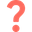
Проанализируйте и изложите содержательный смысл полученных результатов.

*# WRITE YOUR ANSWER*

1. Временной ряд имеет повторяющиеся структуры, алгоритм выделил 6 наиболее характерных из них. Это может указывать на устойчивые паттерны поведения системы (типичные профили суточного потребления, характеризующиеся сезонными и поведенческими факторами)
2. Низкие значения профиля соответствуют стабильным режимам потребления, а пики профиля - аномальные периоды.
3. Найденные мотивы представляют собой разные типы суточных циклов, отражающие привычки и сезонность жизни города.

### **Задача 3.**
Реализуйте самостоятельно функцию `top_k_discords()` в модуле *discords.py*, предназначенную для поиска top-$k$ диссонансов во временном ряде на основе матричного профиля. Чтобы исключить попадание тривиальных совпадений в результирующее множество диссонансов воспользуйтесь функцией `apply_exclusion_zone()` из модуля *utils.py*.

Загрузите временной ряд *nyc_taxi.csv* из директории *./datasets/part1/*, содежащий данные о среднем числе пассажиров NY такси за осень 2014 года.

In [36]:
ts_url = './datasets/part1/nyc_taxi.csv'

ts = pd.read_csv(ts_url, index_col=0, header=0).squeeze().to_numpy()
plot_ts(ts, "Input time series")

In [38]:
# @title
def top_k_discords(matrix_profile: dict, top_k: int = 3) -> dict:
    """
    Find the top-k discords based on matrix profile

    Parameters
    ---------
    matrix_profile: the matrix profile structure
    top_k: number of discords

    Returns
    --------
    discords: top-k discords (indices, distances to its nearest neighbor and the nearest neighbors indices)
    """

    discords_idx = []
    discords_dist = []
    discords_nn_idx = []

    # INSERT YOUR CODE

    mp = matrix_profile['mp'].copy()
    mpi = matrix_profile['mpi'].copy()

    excl_zone = matrix_profile.get('ez', 0)
    if excl_zone == 0:
        sublen = matrix_profile.get('w', matrix_profile.get('sublen', matrix_profile.get('sublen', 1)))
        excl_zone = int(sublen/2)

    for _ in range(top_k):
        max_idx = np.argmax(mp)
        max_val = mp[max_idx]

        if max_val == -np.inf or max_val == np.inf or np.isnan(max_val):
            break

        discords_idx.append(max_idx)
        discords_dist.append(max_val)
        discords_nn_idx.append(mpi[max_idx])

        mp = apply_exclusion_zone(mp, max_idx, excl_zone, -np.inf)

    return {
        'indices' : discords_idx,
        'distances' : discords_dist,
        'nn_indices' : discords_nn_idx
        }

In [39]:
import numpy as np

ts_float = ts.astype(np.float64)

m = 96
excl_zone = int(np.ceil(m / 2))
mp = compute_mp(ts_float, m, excl_zone)

In [40]:
top_k = 15
discords = top_k_discords(mp, top_k)

Выполните визуализацию найденных top-$k$ диссонансов.

In [41]:
plot_discords(mp, discords)

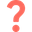
Проанализируйте и изложите содержательный смысл полученных результатов.

*# WRITE YOUR ANSWER*

1. Ряд демонстрирует ярко выраженную периодичность - наблюдаются регулярные колебания соответствующие суточным и, вероятно, недельным циклам активности пассажиров. В течение большей части поведение стабильное: значения повторяются, колебания находятся в узком диапозоне. Тем самым, можно сделать вывод о стабильном транспортном спросе с предсказуемыми пиками.
2. Красные метки на графике показывают наиболее уникальные участки временного ряда. Их локализация в конце наблюдений говорит о том, что аномалия произошла в последние дни осени 2014 года. Содержательно это означает внезапное отклонение от привычного паттерна поведения пассажиропотока. Это говорит о событийном или внешнем воздействии на транспортный спрос, (возможно праздники)

## **Часть 2.** Сегментация повторяющихся активностей.

### **Задача 4.**

Загрузите временной ряд PAMAP *pamap.csv* из директории *./datasets/part2/*, представляющий собой показания закрепленного на человеке виброакселерометра. Данный ряд включает показания, снятые при выполнении человеком трех видов физической активности: ходьба, подъем по лестнице и спуск по лестнице. Необходимо сегментировать временной ряд на основе его матричного профиля для определения того, когда человек шел и когда поднимался/спускался. Поскольку подъем и спуск по лестнице – это схожие действия, поэтому будем считать, что это одна активность.  

In [42]:
ts_url = './datasets/part2/pamap.csv'

ts = pd.read_csv(ts_url, header=None).squeeze().to_numpy()

Визуализируйте временной ряд PAMAP.

In [43]:
plot_ts(ts, "Input time series")

Найдите и визуализируйте матричный профиль временного ряда.

In [46]:
m = 100
excl_zone = m
mp = compute_mp(ts, m, excl_zone)

In [47]:
plot_ts(mp['mp'], "Matrix Profile")

Вычислите порог по формуле, которая представлена в презентации [04 Matrix profile.pdf](https://github.com/mzym/TimeSeriesCourse/blob/main/slides/04%20Matrix%20profile.pdf).

In [51]:
threshold = 8

try:
    mp['mp'] = mp['mp'].astype(float)
except:
    print("Массив mp['mp'] содержит нечисловые значения")

if np.isnan(mp['mp']).any() or np.isinf(mp['mp']).any():
    mp['mp'] = np.nan_to_num(mp['mp'], nan=np.nanmax(mp['mp']), posinf=np.nanmax(mp['mp']), neginf=np.nanmin(mp['mp']))

mp['mp'] = np.where(np.isinf(mp['mp']) | np.isnan(mp['mp']), np.nan, mp['mp'])

mp['mp'] = mp['mp'][~np.isnan(mp['mp'])]

Выполните визуализацию результатов сегментации повторяющихся активностей.

In [52]:
plot_segmentation(mp, threshold)

Загрузите истинную разметку временного ряда PAMAP *pamap_labels.csv*, где 0 означает ходьбу, 1 – подъем по лестнице, 2 – спуск с лестницы. Вычислите точность по метрике accuracy, сравнив полученные результаты по основе матричного профиля с истинной разметкой.

In [54]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

labels_url = './datasets/part2/pamap_labels.csv'
labels = pd.read_csv(labels_url, header=None).squeeze().to_numpy()
labels = np.where(labels == 2, 1, labels)
labels = labels[m:]

mp['mp'] = mp['mp'].astype(float)
mp['mp'] = np.where(np.isinf(mp['mp']) | np.isnan(mp['mp']), np.finfo(np.float64).max, mp['mp'])

valid_indices = np.clip(mp['mp'].astype(int), 0, len(labels) - 1)
labels = labels[valid_indices]

labels_pred = (mp['mp'] < threshold).astype(int)

accuracy = accuracy_score(labels, labels_pred)
print(f"Точность (accuracy): {accuracy*100:.4f}%")

Точность (accuracy): 68.6852%


## **Чaсть 3.** Casy Study: Раскрытие краж электричества подменой счетчиков (meter-swapping detection).


### **Задача 5.**

Рассмотрим практическое применение использования матричного профиля для решения задачи, связанной с раскрытием краж электричества путем подмены счетчиков.

Загрузите временные ряды из директории *./datasets/part3/*, которые были выбраны случайным образом из набора данных (House 1, 2, 3, 4 и 11), содержащего данные потребления электроэнергии 20 жилых домов в Великобритании с 1 января по 23 декабря 2014 года.

In [78]:
path = './datasets/part3/'

house_idx = [1, 2, 3, 4, 11]

filenames = [f"House{i}.csv" for i in house_idx]

consumptions = {}
for house in filenames:
    consumptions[house[:-4]] = pd.read_csv(os.path.join(path, house), header=None, index_col=0)
    consumptions[house[:-4]].index = pd.to_datetime(consumptions[house[:-4]].index, format="%Y-%m-%d %H:%M:%S")

consumptions_df = pd.concat(consumptions, axis=1)
consumptions_df

,House1,House2,House3,House4,House11
,1,1,1,1,1
0,,,,,
2014-01-01 00:00:00,1422.005576,NaN,418.419463,383.617496,NaN
2014-01-01 01:00:00,1707.948669,NaN,248.500000,245.490662,NaN
2014-01-01 02:00:00,1442.025253,NaN,195.945000,228.549153,NaN
2014-01-01 03:00:00,1374.657191,NaN,235.060100,333.189329,NaN
2014-01-01 04:00:00,1757.285235,NaN,200.060000,347.561102,NaN
...,...,...,...,...,...
2014-12-30 19:00:00,775.627087,138.643810,1034.671103,493.303263,178.684008
2014-12-30 20:00:00,475.499072,95.211429,1031.949153,402.149805,458.040777


Далее смоделируем событие замены счетчика. Для этого каждый временной ряд разделим на две части: "Head" (до 1 октября) и "Tail" (после 1 октября). После чего выберем случайным образом 2 временных ряда (например, House1 и House11) и поменяем местами их "Tail" части.

In [79]:
cutoff = pd.to_datetime('2014-10-01')
heads, tails = heads_tails(consumptions, cutoff, house_idx)

# swap Heads and Tails of 1 and 11
swap1, swap2 = 1, 11

consumptions[f'House{swap1}'] = pd.concat([heads[f'H_{swap1}'], tails[f'T_{swap2}']])
consumptions[f'House{swap2}'] = pd.concat([heads[f'H_{swap2}'], tails[f'T_{swap1}']])

heads, tails = heads_tails(consumptions, cutoff, house_idx)

Визуализируйте исходные временные ряды и параллельную оси OY прямую, которая делит временные ряды на "Head" и "Tail" части.

In [80]:
plot_consumptions_ts(consumptions, cutoff, house_idx)

Чтобы найти переставленную пару временных рядов, выполним следующее. Сначала составим временные ряды $H_i$ из всевозможных комбинаций "Head" и "Tail" частей исходных временных рядов $T_K$, где $1 \leq i \leq |T|^2$, $1 \leq K \leq |T|$. В нашем случае, $|T| = 5$.  Далее среди них найдем такую пару временных рядов $(H_i, H_j)$, которая имеет минимальную оценку $swap\_score$. Минимальная оценка $swap\_score$ для пары рядов $(H_i, H_j)$ вычисляется следующим образом:

\begin{equation}
swap\_score(i,j) = \frac{\min{(Head_{H_i} \bowtie Tail_{H_j})}}{\min{(Head_{H_i} \bowtie Tail_{H_i})}+eps},
\end{equation}

где $\bowtie$ – операция нахождения матричного профиля между двумя временными рядами. Матричный профиль между двумя временными рядами содержит расстояния между всеми подпоследовательностями первого временного ряда и их ближайшими соседями, которые являются подпоследовательностями второго временного ряда.

Добавьте в функцию `compute_mp()` в модуле *mp.py* поддежку вычисления матричного профиля между двумя различными временными рядами и найдите пару временных рядов $(H_i, H_j)$, которая имеет минимальную оценку $swap\_score$ среди всех пар.

In [81]:
# @title
def compute_new_mp(ts1, m, exclusion_zone=None, ts2=None):
    if exclusion_zone is None:
        exclusion_zone = math.ceil(m / config.STUMPY_EXCL_ZONE_DENOM)

    m = int(m)

    if ts2 is None:
        mp = stumpy.stump(ts1, m)
    else:
        mp = stumpy.stump(ts1, m, ts2)

    return mp

In [82]:
# @title
def meter_swapping_detection(heads, tails, house_idx, m):
    m = int(m)
    min_score = {'score': float('inf'), 'i': None, 'mp_j': None}

    for i in house_idx:
        head_i = heads[f'H_{i}']
        for j in house_idx:
            if i == j:
                continue

            tail_j = tails[f'T_{j}']

            if hasattr(head_i, 'values'):
                head_i_vals = head_i.values.flatten()
            else:
                head_i_vals = head_i.flatten()

            if hasattr(tail_j, 'values'):
                tail_j_vals = tail_j.values.flatten()
            else:
                tail_j_vals = tail_j.flatten()

            mp = compute_new_mp(head_i_vals, m, ts2=tail_j_vals)
            min_distance = np.min(mp[:, 0])

            if min_distance < min_score['score']:
                min_score['score'] = min_distance
                min_score['i'] = i
                min_score['j'] = j
                min_score['mp_j'] = mp

    return min_score

In [83]:
m = 24 * 4

min_score = meter_swapping_detection(heads, tails, house_idx, m)

/usr/local/lib/python3.12/dist-packages/stumpy/core.py:2257: RuntimeWarning:

divide by zero encountered in divide

/usr/local/lib/python3.12/dist-packages/stumpy/core.py:3703: UserWarning:

Arrays T_A, T_B are not equal, which implies an AB-join. `ignore_trivial` has been automatically set to `False`.



In [84]:
min_i, min_j, mp_j = min_score['i'], min_score['j'], min_score['mp_j']
print(f'Time series with minimum score is (H_{min_i}, T_{min_j}).')

Time series with minimum score is (H_2, T_11).


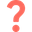
Проанализируйте и изложите содержательный смысл полученных результатов.

*# WRITE YOUR ANSWER*

Проведя расследование установлено, что минимальное значение swap_score соответствует паре рядов H_2 и T_11. Это говорит нам о том, что хвост ряда дома 11 имеет сходство с началом ряда дома 2. Из этого следует большая вероятность того, что данных этих двух домов были подменены/перепутаны